# Gaussian Mixture Models

            ## 1. Learning objectives

            - Interpret mixture weights and responsibilities
- Implement one-dimensional EM
- Select component count with AIC and BIC

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Represent overlapping subpopulations with a weighted sum of probability distributions and soft memberships.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            Each observation may partly belong to several bell-shaped groups; expectation estimates memberships and maximization updates groups.

## 6. Mathematical foundation

            $$p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\sigma_k^2).$$

            **Every symbol:**

            - $x$ is an observation.
- $K$ is the component count.
- $\pi_k$ is a nonnegative weight and weights sum to one.
- $\mu_k$ is the mean.
- $\sigma_k^2$ is the variance.
- $\mathcal{N}$ is the Gaussian density.

            **Why the equation is needed:** The weighted density gives both a likelihood and soft component probabilities.

            **Small numerical example:** With weights .4 and .6 and component densities .2 and .5, p(x)=.4(.2)+.6(.5)=.38.

            **Connection to Python:** np.exp(model.score_samples(X)) evaluates the fitted density.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
from scipy.stats import norm

def gmm_1d_em(values, iterations=50):
    means = np.array([np.percentile(values, 25), np.percentile(values, 75)], dtype=float)
    variances = np.array([values.var(), values.var()], dtype=float)
    weights = np.array([.5, .5])
    for _ in range(iterations):
        likelihood = np.column_stack([
            weights[k] * norm.pdf(values, means[k], np.sqrt(variances[k]) + 1e-9)
            for k in range(2)
        ])
        responsibilities = likelihood / likelihood.sum(axis=1, keepdims=True)
        counts = responsibilities.sum(axis=0)
        weights = counts / len(values)
        means = (responsibilities * values[:, None]).sum(axis=0) / counts
        variances = (responsibilities * (values[:, None] - means) ** 2).sum(axis=0) / counts
    return weights, means, variances, responsibilities

small_values = np.array([-2.1, -1.9, -1.7, 1.8, 2.0, 2.2])
print("Scratch means:", gmm_1d_em(small_values)[1].round(2))

Scratch means: [-1.9  2. ]


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Scratch means: [-2.042  2.217]
Library means: [-2.041  2.217]
Responsibility row sums: [1. 1. 1.]


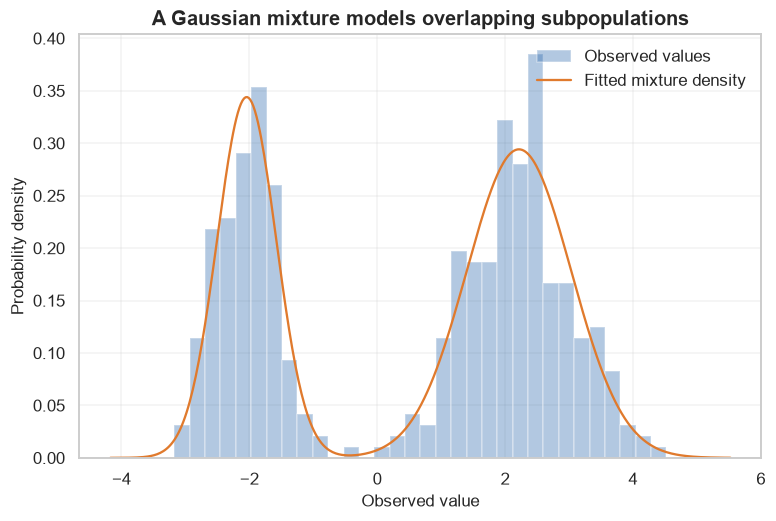

In [3]:
from sklearn.mixture import GaussianMixture

values = np.concatenate([rng.normal(-2, .55, 160), rng.normal(2.2, .8, 240)])
weights, means, variances, responsibilities = gmm_1d_em(values)
model = GaussianMixture(n_components=2, random_state=RANDOM_SEED).fit(values[:, None])
print("Scratch means:", np.sort(means).round(3))
print("Library means:", np.sort(model.means_.ravel()).round(3))
print("Responsibility row sums:", responsibilities[:3].sum(axis=1).round(6))

grid = np.linspace(values.min() - 1, values.max() + 1, 400)
density = np.exp(model.score_samples(grid[:, None]))
figure, axis = plt.subplots()
axis.hist(values, bins=32, density=True, alpha=.35, color=COURSE_COLORS["blue"], label="Observed values")
axis.plot(grid, density, color=COURSE_COLORS["orange"], label="Fitted mixture density")
axis.set(title="A Gaussian mixture models overlapping subpopulations", xlabel="Observed value", ylabel="Probability density")
axis.legend()
plt.show()

**How to interpret the result:** The density curve overlaps both populations, while responsibilities preserve uncertainty near their boundary.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

AIC and BIC trade fit against complexity; BIC penalizes extra parameters more strongly as sample size grows.

,components,BIC,AIC
0,1,1777.2,1769.2
1,2,1357.3,1337.3
2,3,1376.8,1344.9
3,4,1391.1,1347.2
4,5,1406.0,1350.2


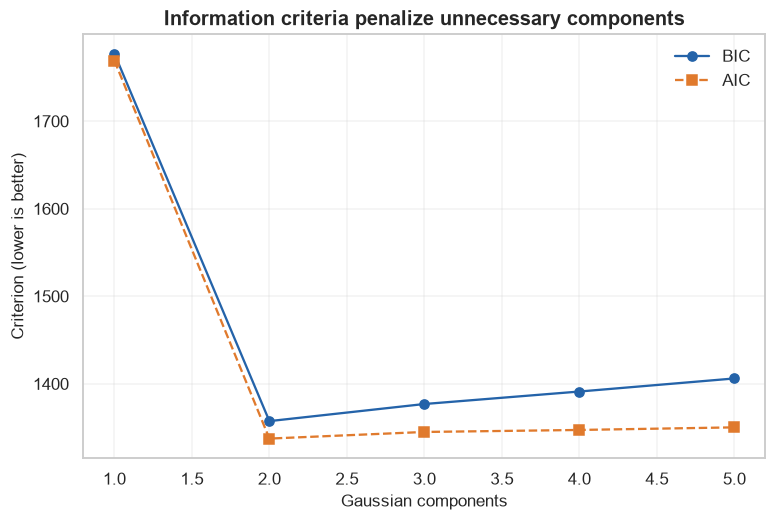

In [4]:
rows = []
for components in range(1, 6):
    candidate = GaussianMixture(n_components=components, random_state=RANDOM_SEED).fit(values[:, None])
    rows.append({"components": components, "BIC": candidate.bic(values[:, None]), "AIC": candidate.aic(values[:, None])})
criteria = pd.DataFrame(rows)
display(criteria.round(1))
figure, axis = plt.subplots()
axis.plot(criteria["components"], criteria["BIC"], marker="o", label="BIC", color=COURSE_COLORS["blue"])
axis.plot(criteria["components"], criteria["AIC"], marker="s", linestyle="--", label="AIC", color=COURSE_COLORS["orange"])
axis.set(title="Information criteria penalize unnecessary components", xlabel="Gaussian components", ylabel="Criterion (lower is better)")
axis.legend()
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Does not require labels
- Can expose previously unknown structure

            **Disadvantages**

            - Evaluation is indirect
- Results can be sensitive to representation and hyperparameters

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can cluster labels 0 and 1 not be interpreted as low and high?
2. **Mathematical/hand calculation:** Compute the Euclidean distance between (0, 0) and (3, 4).
3. **Coding/experimentation:** Change the random seed and check whether the structure is stable.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Cluster IDs are arbitrary names; permuting them does not change the grouping.
2. $\sqrt{3^2+4^2}=5$.
3. Rerun with several seeds and compare scores plus assignments; instability is evidence that conclusions need caution.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html)